# PyTorch fit, heat maps, and final formula

## Imports and constants

In [1]:
import os
import json
import glob

import numpy as np
import torch
import matplotlib
if "get_ipython" not in globals():
    matplotlib.use("Agg")         
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)   
torch.manual_seed(0)
torch.set_num_threads(1)   
plt.rcParams.update({"font.size": 10, "mathtext.fontset": "cm",
                     "font.family": "serif", "figure.dpi": 160})


DATA_DIR = "data"
FIG_DIR  = "fig"
SEED     = 1234


BASIS    = ["P:one", "P:d", "P:logC", "F1:one", "F1:d", "F2:one", "B2:one", "V:one"]
ZSTAR, QSW    = 0.6, 9.0           
BUMPS    = {"B2": (-0.45, 0.50)}   
DEEP     = 15                       
DEEP_CAP = 0.0020                  
CAP_DEEP = np.log1p(DEEP_CAP)       
CAP      = 1.05                     

## Load the cached features (built by `generate_features.ipynb`)

In [2]:
def _part_index(p):
    return int(p.rsplit("_part", 1)[1].split(".npz")[0])

def load_features(data_dir):
    paths = sorted(glob.glob(os.path.join(data_dir, "fit_curve_features_part*.npz")),
                   key=_part_index)
    if not paths:
        raise FileNotFoundError(
            "No feature cache found. Run generate_features.ipynb first to build "
            "data/fit_curve_features_part*.npz.")
    keys = ("uni", "zeta", "F1", "F2", "F3", "L0", "logC", "lnR", "lam", "d", "a0", "k")
    parts = []
    for p in paths:
        with np.load(p) as z:
            parts.append({k: z[k] for k in keys})
    return {k: np.concatenate([pp[k] for pp in parts], axis=0) for k in keys}, len(paths)

F, n_parts = load_features(DATA_DIR)
n, m = F["lnR"].shape
print(f"loaded {n} curves x {m} points from {n_parts} cache parts")

loaded 4096 curves x 1500 points from 4 cache parts


## Build the linear design tensor and the fixed model pieces

In [3]:
B2_MU, B2_SIG = BUMPS["B2"]
zeta = F["zeta"]
W    = np.where(zeta <= 0, 1.0,
                1.0 / (1.0 + np.exp(np.clip(QSW * (zeta - ZSTAR), -60, 60))))
omW  = 1.0 - W
B2   = np.exp(-0.5 * ((F["lam"] - B2_MU) / B2_SIG) ** 2)
V    = 4.0 * W * omW
d, logC, L0 = F["d"][:, None], F["logC"][:, None], F["L0"][:, None]


target = F["lnR"] - W * F["uni"] - omW * (L0 - F["F3"])
cols = {
    "P:one":  omW,            "P:d":    omW * d,          "P:logC": omW * logC,
    "F1:one": omW * F["F1"],  "F1:d":   omW * d * F["F1"],
    "F2:one": omW * F["F2"],  "B2:one": B2,               "V:one":  V,
}
X  = np.stack([cols[b] for b in BASIS], axis=-1)        # (n, m, 8)
Xf = X.reshape(n * m, 8); yf = target.reshape(n * m)
print("design tensor X:", X.shape)


rng  = np.random.default_rng(SEED)
perm = rng.permutation(n)
is_tr = np.zeros(n, bool); is_tr[perm[: int(0.8 * n)]] = True
print(f"{is_tr.sum()} train / {(~is_tr).sum()} verify curves")

def predict_resid(beta):
    return X @ np.asarray(beta) - target

def accuracy(beta):
    e = 100.0 * np.abs(np.expm1(predict_resid(beta)))
    return e.max(1), e.mean(1), e[:, :DEEP].max(1)        

design tensor X: (4096, 1500, 8)
3276 train / 820 verify curves


## PyTorch fit 

In [4]:
col  = np.arange(m)
lamw = (F["lam"] > np.log(0.15)) & (F["lam"] < np.log(5.0))      
keep = (lamw & (col % 5 == 0)[None, :]) | (~lamw & (col % 100 == 0)[None, :])
fi   = np.flatnonzero(keep); fi = fi[is_tr[fi // m]]           
tr_rows = np.where(is_tr)[0]
deep_fi = (tr_rows[:, None] * m + np.arange(DEEP)[None, :]).ravel()

Xs = torch.from_numpy(np.ascontiguousarray(Xf[fi]))
ys = torch.from_numpy(np.ascontiguousarray(yf[fi]))
Xd = torch.from_numpy(np.ascontiguousarray(Xf[deep_fi]))
yd = torch.from_numpy(np.ascontiguousarray(yf[deep_fi]))

def report(beta_t, label):
    w, me, dp = accuracy(beta_t.detach().numpy())
    print(f"  {label:14s} train worst {w[is_tr].max():6.3f} %  "
          f"mean {me[is_tr].mean():7.4f} %  deep {dp[is_tr].max():6.4f} %")


beta = torch.zeros(8, requires_grad=True)
Xt = torch.from_numpy(np.ascontiguousarray(Xf[np.repeat(is_tr, m)]))
yt = torch.from_numpy(np.ascontiguousarray(yf[np.repeat(is_tr, m)]))
opt = torch.optim.LBFGS([beta], lr=1.0, max_iter=400, tolerance_grad=1e-16,
                        tolerance_change=1e-18, line_search_fn="strong_wolfe")
def ls_closure():
    opt.zero_grad(); l = ((Xt @ beta - yt) ** 2).mean(); l.backward(); return l
opt.step(ls_closure)
report(beta, "least squares")


print("stage 1 - minimax (find the worst-case optimum t*):")
for T, lam in [(2e2,1e4),(5e2,1e5),(1e3,1e6),(2e3,1e7),(4e3,1e8),(8e3,1e9),(1.6e4,1e10)]:
    opt = torch.optim.LBFGS([beta], lr=1.0, max_iter=150, line_search_fn="strong_wolfe")
    def cl_mm():
        opt.zero_grad()
        r = (Xs @ beta - ys).abs()
        pen = torch.relu((Xd @ beta - yd).abs() - CAP_DEEP)
        L = torch.logsumexp(T * r, 0) / T + lam * (pen ** 2).mean()   
        L.backward(); return L
    opt.step(cl_mm)
report(beta, "minimax")
w_tr  = accuracy(beta.detach().numpy())[0][is_tr].max()
tstar = np.log1p(w_tr / 100.0); cap = CAP * tstar


print("stage 2 - capped mean polish:")
lam_sub = np.exp(F["lam"].ravel()[fi])
wobj = torch.from_numpy(np.where(lam_sub > np.log(0.15), 5.0, 100.0))
delta = 1e-4
for muw, mud in [(3e4,3e8),(1e5,1e9),(3e5,3e9),(1e6,1e10),(3e6,3e10)]:
    opt = torch.optim.LBFGS([beta], lr=1.0, max_iter=200, line_search_fn="strong_wolfe")
    def cl_pol():
        opt.zero_grad()
        r = Xs @ beta - ys; ar = r.abs()
        hub  = torch.where(ar < delta, 0.5 * r * r / delta, ar - 0.5 * delta)  # smooth |r|
        mean = (wobj * hub).sum() / wobj.sum()
        pen_all = (torch.relu(ar - cap) ** 2).mean()
        pen_dp  = (torch.relu((Xd @ beta - yd).abs() - CAP_DEEP) ** 2).mean()
        L = mean + muw * pen_all + mud * pen_dp
        L.backward(); return L
    opt.step(cl_pol)
report(beta, "mean polish")

beta_fit = beta.detach().numpy()
worst, meanpc, deep = accuracy(beta_fit)
print("\n               worst pointwise    per-curve mean   deep plateau")
for tag, sel in (("train ", is_tr), ("verify", ~is_tr)):
    print(f"pytorch fit {tag}:  {worst[sel].max():7.3f} %        "
          f"{meanpc[sel].mean():7.4f} %      {deep[sel].max():6.3f} %")
print(f"\nconstants (8 linear; blend fixed zeta_*={ZSTAR}, q_sw={QSW}):")
for nm, b in zip(BASIS, beta_fit):
    print(f"  w[{nm:>7s}] = {b:+.16e}")

  least squares  train worst  2.357 %  mean  0.2205 %  deep 0.5274 %
stage 1 - minimax (find the worst-case optimum t*):
  minimax        train worst  2.020 %  mean  0.3382 %  deep 0.2000 %
stage 2 - capped mean polish:
  mean polish    train worst  2.171 %  mean  0.2294 %  deep 0.1996 %

               worst pointwise    per-curve mean   deep plateau
pytorch fit train :    2.171 %         0.2294 %       0.200 %
pytorch fit verify:    2.149 %         0.2351 %       0.178 %

constants (8 linear; blend fixed zeta_*=0.6, q_sw=9.0):
  w[  P:one] = +1.0956775997952495e-02
  w[    P:d] = -1.3827721841977367e-01
  w[ P:logC] = +6.5096786787420546e-01
  w[ F1:one] = -9.4797985744821511e-01
  w[   F1:d] = +8.2994446602874129e-03
  w[ F2:one] = -3.3832224561972329e-01
  w[ B2:one] = +5.4629434144151216e-02
  w[  V:one] = +7.5695507513252935e-02


## Write the constants JSON

In [5]:
out = dict(
    model="lnR = W*uni + (1-W)*de + bumps (PyTorch fit; see final-formula cell)",
    basis=list(BASIS),
    constants={nm: float(b) for nm, b in zip(BASIS, beta_fit)},
    blend=dict(zeta_star=float(ZSTAR), q_sw=float(QSW)),
    bump_shapes={k: dict(mu=v[0], sigma=v[1]) for k, v in BUMPS.items()
                 if any(nm.startswith(k + ":") for nm in BASIS)},
    accuracy_pct=dict(
        train=dict(worst=float(worst[is_tr].max()), mean=float(meanpc[is_tr].mean()),
                   deep_plateau=float(deep[is_tr].max())),
        verify=dict(worst=float(worst[~is_tr].max()), mean=float(meanpc[~is_tr].mean()),
                    deep_plateau=float(deep[~is_tr].max())),
    ),
    split_seed=SEED,
    cap_factor=CAP,
    deep_cap=DEEP_CAP,
)
os.makedirs(DATA_DIR, exist_ok=True)
jp = os.path.join(DATA_DIR, "fit_curve_constants.json")
with open(jp, "w", encoding="utf-8") as f:
    json.dump(out, f, indent=2)
print("wrote", jp)

wrote data\fit_curve_constants.json


## Figures: comparison curves and error heat maps

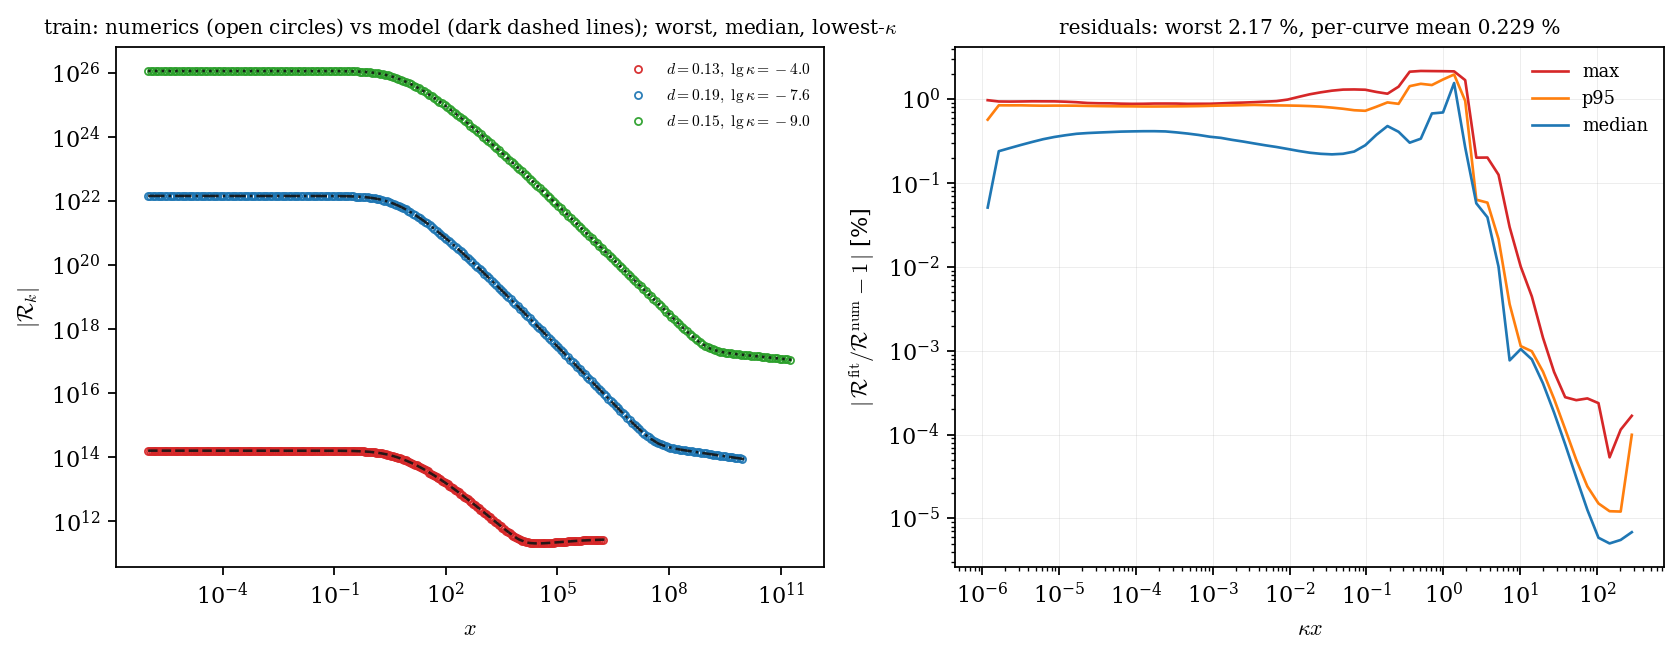

wrote fig\fit_curve_compare_train.png


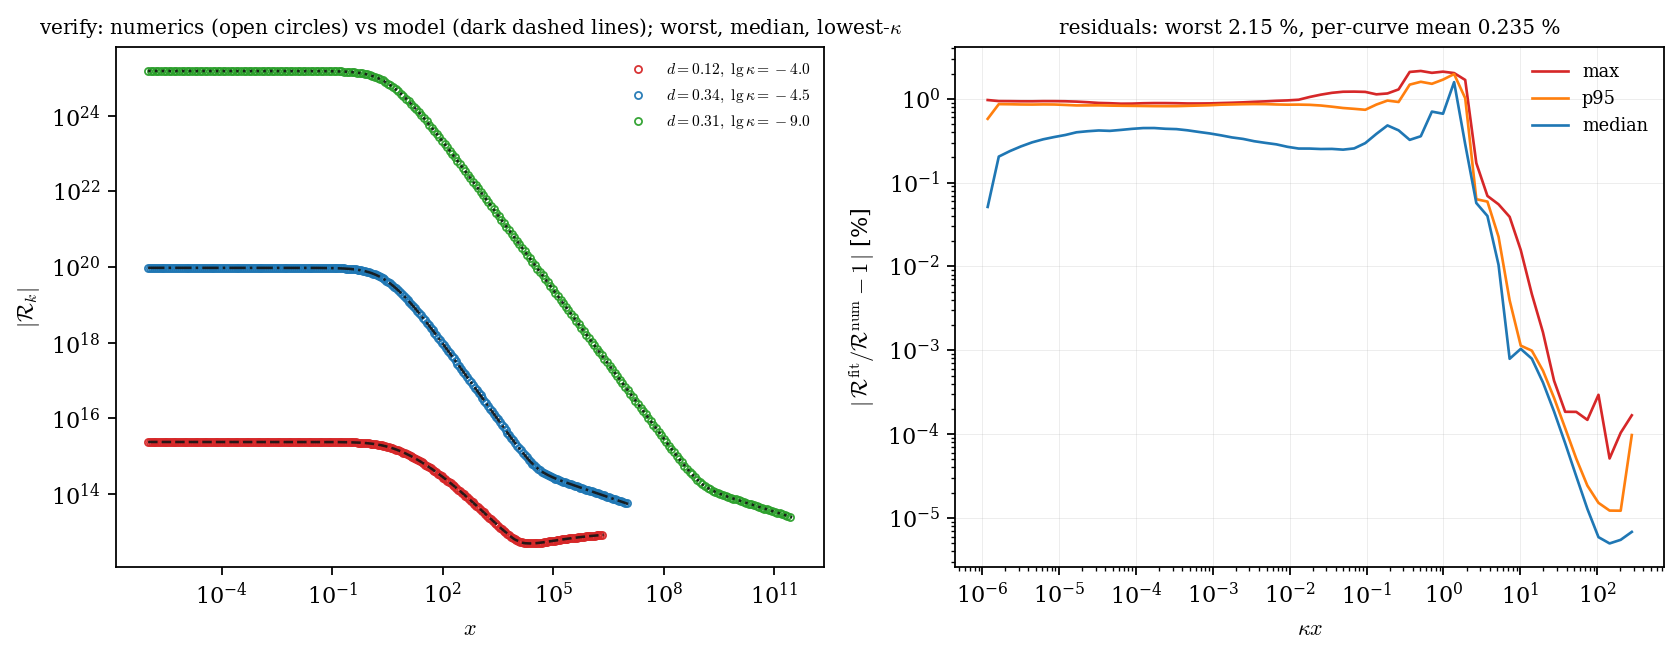

wrote fig\fit_curve_compare_verify.png


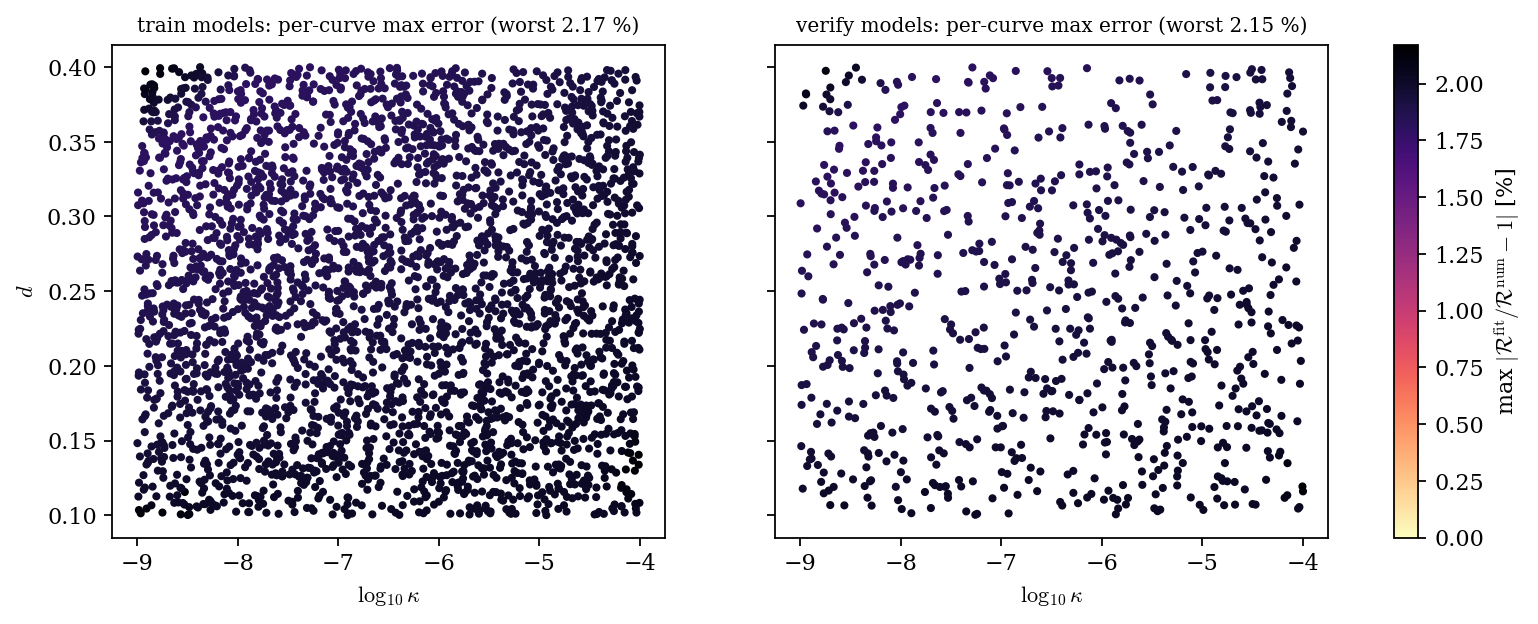

wrote fig\fit_curve_heatmaps.png


In [6]:
lgk = np.log10(F["k"])
R_full = predict_resid(beta_fit)            
os.makedirs(FIG_DIR, exist_ok=True)


for tag, sel in (("train", is_tr), ("verify", ~is_tr)):
    ids = np.where(sel)[0]
    show = [ids[np.argmax(worst[ids])],
            ids[np.argsort(worst[ids])[len(ids) // 2]],
            ids[np.argmin(F["k"][ids])]]
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
    plot_styles = (("C3", "--"), ("C0", "-."), ("C2", ":"))
    for i, (cstr, lstr) in zip(show, plot_styles):
        x = np.exp(F["lam"][i]) / F["k"][i]
        a1.loglog(x[::6], np.exp(F["lnR"][i])[::6], "o", ms=3.2,
                  mfc="none", mec=cstr, mew=0.8, alpha=0.95,
                  label=rf"$d={F['d'][i]:.2f},\ \lg\kappa={lgk[i]:.1f}$")
        a1.loglog(x, np.exp(F["lnR"][i] + R_full[i]), lstr,
                  lw=1.15, color="0.08", alpha=0.9, zorder=3)
    a1.set_xlabel(r"$x$"); a1.set_ylabel(r"$|\mathcal{R}_k|$")
    a1.legend(fontsize=7, frameon=False)
    a1.set_title(f"{tag}: numerics (open circles) vs model (dark dashed lines); worst, median, lowest-$\\kappa$",
                 fontsize=9)

    kx = np.exp(F["lam"][sel].ravel())
    e  = 100.0 * np.abs(np.expm1(R_full[sel].ravel()))
    bins = np.geomspace(1e-6, kx.max(), 60)
    ib = np.clip(np.digitize(kx, bins) - 1, 0, 58)
    p50 = np.array([np.median(e[ib == j]) if (ib == j).any() else np.nan for j in range(59)])
    p95 = np.array([np.percentile(e[ib == j], 95) if (ib == j).any() else np.nan for j in range(59)])
    pmx = np.array([e[ib == j].max() if (ib == j).any() else np.nan for j in range(59)])
    bc = np.sqrt(bins[:-1] * bins[1:])
    a2.loglog(bc, pmx, "-", color="C3", lw=1.2, label="max")
    a2.loglog(bc, p95, "-", color="C1", lw=1.2, label="p95")
    a2.loglog(bc, p50, "-", color="C0", lw=1.2, label="median")
    a2.set_xlabel(r"$\kappa x$")
    a2.set_ylabel(r"$|\,\mathcal{R}^{\rm fit}/\mathcal{R}^{\rm num}-1\,|$ [%]")
    a2.set_title(f"residuals: worst {worst[sel].max():.2f} %, "
                 f"per-curve mean {meanpc[sel].mean():.3f} %", fontsize=9)
    a2.legend(fontsize=8, frameon=False); a2.grid(alpha=0.25, lw=0.4)
    plt.tight_layout()
    fpath = os.path.join(FIG_DIR, f"fit_curve_compare_{tag}.png")
    plt.savefig(fpath, bbox_inches="tight")
    plt.close(fig) if matplotlib.get_backend().lower() == "agg" else plt.show()
    print("wrote", fpath)


fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.0), sharey=True)
vmax = worst.max()
for ax, tag, sel in ((axes[0], "train", is_tr), (axes[1], "verify", ~is_tr)):
    s = ax.scatter(lgk[sel], F["d"][sel], c=worst[sel], s=7, cmap="magma_r",
                   vmin=0, vmax=vmax)
    ax.set_xlabel(r"$\log_{10}\kappa$")
    ax.set_title(f"{tag} models: per-curve max error (worst {worst[sel].max():.2f} %)",
                 fontsize=9)
axes[0].set_ylabel(r"$d$")
plt.colorbar(s, ax=axes, fraction=0.025,
             label=r"max $|\mathcal{R}^{\rm fit}/\mathcal{R}^{\rm num}-1|$ [%]")
fpath = os.path.join(FIG_DIR, "fit_curve_heatmaps.png")
plt.savefig(fpath, bbox_inches="tight")
plt.close(fig) if matplotlib.get_backend().lower() == "agg" else plt.show()
print("wrote", fpath)

## Final fitted formula and its LaTeX version

In [7]:
import json
import os

if not all(name in globals() for name in ("BASIS", "beta_fit", "BUMPS", "ZSTAR", "QSW")):
    _data_dir = globals().get("DATA_DIR", "data")
    with open(os.path.join(_data_dir, "fit_curve_constants.json"), encoding="utf-8") as f:
        _cfg = json.load(f)
    BASIS = _cfg["basis"]
    beta_fit = [_cfg["constants"][nm] for nm in BASIS]
    ZSTAR = _cfg["blend"]["zeta_star"]
    QSW = _cfg["blend"]["q_sw"]
    BUMPS = {name: (shape["mu"], shape["sigma"])
             for name, shape in _cfg["bump_shapes"].items()}

c = {nm: float(b) for nm, b in zip(BASIS, beta_fit)}
mu, sig = BUMPS["B2"]

formula_text = f"""
Fitted final formula (PyTorch)
==============================
For one cached point (d, alpha0, kappa, x), define y = 1 + x and lam = ln(kappa*x).

ln|R_k(x)| = W*uni + (1 - W)*de {c['B2:one']:+.16e}*B2 {c['V:one']:+.16e}*V

de = L0 - F3
     {c['P:one']:+.16e}
     {c['P:d']:+.16e}*d
     {c['P:logC']:+.16e}*logC
     + ({c['F1:one']:+.16e} {c['F1:d']:+.16e}*d)*F1
     {c['F2:one']:+.16e}*F2

Blend and bump terms:
  W  = 1                                                   if zeta <= 0
  W  = 1 / (1 + exp({QSW:.16e}*(zeta - {ZSTAR:.16e})))    if zeta > 0
  V  = 4*W*(1 - W)
  B2 = exp(-0.5*((lam - ({mu:+.16e}))/{sig:.16e})**2)

Generated feature definitions:
  xt solves omega2(xt; d, alpha0, kappa) = 0, starting from xt = 1/kappa.
  s = d omega2/dx evaluated at x = xt.
  zeta = -sign(s)*abs(s)**(1/3)*(x - xt)
  P = (abs(zeta)/abs(omega2(x)))**(1/4)
      with P = abs(s)**(-1/6) at the turning point.
  uni = 0.5*ln(pi/2) + ln(P) + 0.5*ln(Ai(zeta)**2 + Bi(zeta)**2) - ln(z(x))

  Phi(x) = integral from y=1+x to y_t=1+xt of sqrt(max(-omega2(y-1), 0)) dy, set to 0 when y >= y_t
  x0 = first x grid point stored for this curve
  F1(x) = Phi(x0) - Phi(x)
  F2(x) = 0.5*ln(abs(omega2(x))) - 0.5*ln(abs(omega2(x0)))
  F3(x) = ln(z(x)) - ln(z(x0))

Plateau constants:
  A = 3*(1+d)**2
  q = kappa**d
  nu = sqrt(9/4 + A*q*(1-q))
  U = A*(1-q)/(nu + 3/2)
  J = 3 + sqrt(A)*atan(U/sqrt(A)) + (3/2)*ln(A/(A + U**2)) - A*(3 + U)/(A + U**2)
  L0 = -0.5*ln(2) - 0.5*ln(alpha0) - 1.5*ln(kappa) - (1+d)/d + J/d
  logC = (2*nu - 3)*ln(2) + 2*(gammaln(nu) - gammaln(3/2))

Background functions:
  H     = (1+d)*y**(-1-d)
  a     = exp(((1+d)/d)*y**(-d))
  alpha = alpha0*y**(2*d)
  eps   = 1 - y**d
  eta   = -d*y**(2*d)/((1+d)*(y**d - 1))
  beta  = -(2*d/(1+d))*y**d

  z(x) = sqrt(abs(z2(x)))
  z2 = 2*a**2*alpha*(2*kappa**2 + 3*alpha*H**2) / (4*kappa**2 + H**2*alpha*(6 + alpha - 2*eps))

  omega2(x) = cR2(x)*kappa**2 - zddz(x)
  zddz(x) = 0.5*d2[ln(z2)]/dx2 + 0.25*(d[ln(z2)]/dx)**2

  cR2 = (8*kappa**4 + H**2*B1*kappa**2 + H**4*B2c) / (8*kappa**4 + H**2*A1*kappa**2 + H**4*A2)
  B1  = 2*(alpha*(-4*beta + 2*eps + alpha) + 4*eps*(6 + beta - 2*eps + eta))
  B2c = alpha*(-(alpha - 2*eps)**2 + 36*eps + 6*(alpha*(-1 - beta + eps) + 2*eps*(1 - eps + eta)))
  A1  = 2*alpha*(12 + alpha - 2*eps)
  A2  = 3*alpha**2*(6 + alpha - 2*eps)

Basis weights:
""".strip()

print(formula_text)
for nm in BASIS:
    print(f"  {nm:>7s}: {c[nm]:+.16e}")

latex = (
    r"\begin{aligned}"
    r"\ln|\mathcal{R}_k(x)| &= W\,\mathrm{uni} + (1-W)\,\mathrm{de}"
    + f"{c['B2:one']:+.6f}" + r"\,B_2" + f"{c['V:one']:+.6f}" + r"\,V \\[2pt]"
    r"\mathrm{de} &= L_0 - F_3"
    + f"{c['P:one']:+.6f}" + f"{c['P:d']:+.6f}" + r"\,d"
    + f"{c['P:logC']:+.6f}" + r"\,\log C"
    + r"+\left(" + f"{c['F1:one']:+.6f}" + f"{c['F1:d']:+.6f}" + r"\,d\right)F_1"
    + f"{c['F2:one']:+.6f}" + r"\,F_2 \\[2pt]"
    r"W &= \begin{cases}1, & \zeta\le 0 \\[2pt]"
    r"\left(1+e^{q_{sw}(\zeta-\zeta_*)}\right)^{-1}, & \zeta>0\end{cases},\quad "
    r"V = 4W(1-W),\quad B_2 = e^{-(\lambda-\mu)^2/(2\sigma^2)} \\[2pt]"
    + r"\lambda &= \ln(\kappa x),\quad \zeta_* = " + f"{ZSTAR:g}"
    + r",\quad q_{sw} = " + f"{QSW:g}"
    + r",\quad \mu = " + f"{mu:g}" + r",\quad \sigma = " + f"{sig:g}"
    r"\end{aligned}"
)
feature_latex = r"""
\begin{aligned}
\mathrm{uni} &= {1\over2}\ln{\pi\over2} + \ln P
  + {1\over2}\ln\!\left[Ai(\zeta)^2 + Bi(\zeta)^2\right] - \ln z(x),\\
P &= \left({|\zeta|\over |\omega^2(x)|}\right)^{1/4},\quad
\zeta = -\operatorname{sign}(s)|s|^{1/3}(x-x_t),\\
\omega^2(x_t)&=0,\quad s = \omega^{2\prime}(x_t),\\
F_1(x) &= \Phi(x_0)-\Phi(x),\quad
F_2(x) = {1\over2}\ln|\omega^2(x)|-{1\over2}\ln|\omega^2(x_0)|,\\
F_3(x) &= \ln z(x)-\ln z(x_0),\quad
\Phi(x)=0\ (1+x\ge 1+x_t),\quad \Phi(x)=\int_{1+x}^{1+x_t}\sqrt{\max[-\omega^2(y-1),0]}\,dy\ (1+x<1+x_t).
\end{aligned}
""".strip()

print("\nLaTeX source (main formula):\n")
print(latex)
print("\nLaTeX source (feature definitions):\n")
print(feature_latex)
try:
    from IPython.display import display, Math
    display(Math(latex))
    display(Math(feature_latex))
except Exception:
    pass

Fitted final formula (PyTorch)
For one cached point (d, alpha0, kappa, x), define y = 1 + x and lam = ln(kappa*x).

ln|R_k(x)| = W*uni + (1 - W)*de +5.4629434144151216e-02*B2 +7.5695507513252935e-02*V

de = L0 - F3
     +1.0956775997952495e-02
     -1.3827721841977367e-01*d
     +6.5096786787420546e-01*logC
     + (-9.4797985744821511e-01 +8.2994446602874129e-03*d)*F1
     -3.3832224561972329e-01*F2

Blend and bump terms:
  W  = 1                                                   if zeta <= 0
  W  = 1 / (1 + exp(9.0000000000000000e+00*(zeta - 5.9999999999999998e-01)))    if zeta > 0
  V  = 4*W*(1 - W)
  B2 = exp(-0.5*((lam - (-4.5000000000000001e-01))/5.0000000000000000e-01)**2)

Generated feature definitions:
  xt solves omega2(xt; d, alpha0, kappa) = 0, starting from xt = 1/kappa.
  s = d omega2/dx evaluated at x = xt.
  zeta = -sign(s)*abs(s)**(1/3)*(x - xt)
  P = (abs(zeta)/abs(omega2(x)))**(1/4)
      with P = abs(s)**(-1/6) at the turning point.
  uni = 0.5*ln(pi/2) + ln(P) + 0.5

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [8]:
import json
import os

if not all(name in globals() for name in ("BASIS", "beta_fit")):
    _data_dir = globals().get("DATA_DIR", "data")
    with open(os.path.join(_data_dir, "fit_curve_constants.json"), encoding="utf-8") as f:
        _cfg = json.load(f)
    BASIS = _cfg["basis"]
    beta_fit = [_cfg["constants"][nm] for nm in BASIS]

c = {nm: float(b) for nm, b in zip(BASIS, beta_fit)}
p1, p_d, p_C = c["P:one"], c["P:d"], c["P:logC"]

plateau_text = f"""
Plateau asymptotic formula
==========================
On the frozen plateau, the normalized features satisfy F1 = F2 = F3 = 0.
The super-horizon branch therefore reduces to the 3-constant plateau formula:

ln|R_k|_plateau = L0 + p1 + p_d*d + p_C*logC
                 = L0 {p1:+.16e} {p_d:+.16e}*d {p_C:+.16e}*logC

Fitted plateau constants:
  p1  = {p1:+.16e}
  p_d = {p_d:+.16e}
  p_C = {p_C:+.16e}

Analytic pieces:
  A = 3*(1+d)**2
  q = kappa**d
  nu = sqrt(9/4 + A*q*(1-q))
  U = A*(1-q)/(nu + 3/2)
  J = 3 + sqrt(A)*atan(U/sqrt(A)) + (3/2)*ln(A/(A + U**2)) - A*(3 + U)/(A + U**2)
  L0 = -0.5*ln(2) - 0.5*ln(alpha0) - 1.5*ln(kappa) - (1+d)/d + J/d
  logC = (2*nu - 3)*ln(2) + 2*(gammaln(nu) - gammaln(3/2))
""".strip()

print(plateau_text)

plateau_latex = (
    r"\begin{aligned}"
    r"\ln|\mathcal{R}_k|_{\rm plateau} &= L_0"
    + f"{p1:+.6f}" + f"{p_d:+.6f}" + r"\,d"
    + f"{p_C:+.6f}" + r"\,\log C \\[2pt]"
    r"L_0 &= -{1\over2}\ln 2 - {1\over2}\ln\alpha_0 - {3\over2}\ln\kappa"
    r" - {1+d\over d} + {J\over d} \\[2pt]"
    r"J &= 3 + \sqrt{A}\arctan\!\left({U\over\sqrt{A}}\right)"
    r" + {3\over2}\ln\!\left({A\over A+U^2}\right) - {A(3+U)\over A+U^2} \\[2pt]"
    r"A &= 3(1+d)^2,\quad q=\kappa^d,\quad"
    r"\nu=\sqrt{{9\over4}+Aq(1-q)},\quad U={A(1-q)\over \nu+3/2} \\[2pt]"
    r"\log C &= (2\nu-3)\ln 2 + 2\left[\ln\Gamma(\nu)-\ln\Gamma(3/2)\right]"
    r"\end{aligned}"
)

print("\nLaTeX source:\n")
print(plateau_latex)
try:
    from IPython.display import display, Math
    display(Math(plateau_latex))
except Exception:
    pass

Plateau asymptotic formula
On the frozen plateau, the normalized features satisfy F1 = F2 = F3 = 0.
The super-horizon branch therefore reduces to the 3-constant plateau formula:

ln|R_k|_plateau = L0 + p1 + p_d*d + p_C*logC
                 = L0 +1.0956775997952495e-02 -1.3827721841977367e-01*d +6.5096786787420546e-01*logC

Fitted plateau constants:
  p1  = +1.0956775997952495e-02
  p_d = -1.3827721841977367e-01
  p_C = +6.5096786787420546e-01

Analytic pieces:
  A = 3*(1+d)**2
  q = kappa**d
  nu = sqrt(9/4 + A*q*(1-q))
  U = A*(1-q)/(nu + 3/2)
  J = 3 + sqrt(A)*atan(U/sqrt(A)) + (3/2)*ln(A/(A + U**2)) - A*(3 + U)/(A + U**2)
  L0 = -0.5*ln(2) - 0.5*ln(alpha0) - 1.5*ln(kappa) - (1+d)/d + J/d
  logC = (2*nu - 3)*ln(2) + 2*(gammaln(nu) - gammaln(3/2))

LaTeX source:

\begin{aligned}\ln|\mathcal{R}_k|_{\rm plateau} &= L_0+0.010957-0.138277\,d+0.650968\,\log C \\[2pt]L_0 &= -{1\over2}\ln 2 - {1\over2}\ln\alpha_0 - {3\over2}\ln\kappa - {1+d\over d} + {J\over d} \\[2pt]J &= 3 + \sqrt{A}\arct

<IPython.core.display.Math object>